> [返回仓库首页](../README.md) · [查看可视化学习路线](../docs/learning-roadmap.md)

建议按路线图顺序学习本章。

# 06 K 近邻（KNN）：距离、局部投票与回归平均

**本章目标**：理解 KNN 如何用邻域完成分类与回归，掌握距离、投票、加权、参数 `k`、
标准化与维数灾难，并完成 NumPy 手写和 sklearn 真实案例。

> 数据来自固定随机种子或 sklearn 内置数据；选择包含 NumPy、Matplotlib、scikit-learn 的内核后可直接 Run All。

## 模型简介与学习参考

K 近邻（KNN）通过查询点周围的训练样本作局部预测：离散目标用投票得到分类，连续目标用平均得到回归。

| 项目 | 内容 |
|---|---|
| 模型定位 | 基于实例、非参数、惰性学习的监督模型 |
| 核心思想 | 相似样本通常拥有相似目标，预测由最近邻决定 |
| 适用任务 | 分类、回归、相似样本检索和局部基线 |
| 主要优点 | 原理直观；训练成本低；能形成非线性边界 |
| 主要限制 | 预测成本较高；对尺度、`k`、无关特征和高维空间敏感 |

**学习参考**：

- 周志华《机器学习》（西瓜书）：k 近邻学习；
- [Datawhale《南瓜书》](https://github.com/datawhalechina/pumpkin-book)；
- [scikit-learn：Nearest Neighbors](https://scikit-learn.org/stable/modules/neighbors.html)；
- [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) 与
  [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)；
- [ML-From-Scratch](https://github.com/eriklindernoren/ML-From-Scratch)：参考从零实现的代码组织。

本章按 **原理推导 → NumPy 手写分类 → sklearn 分类 → sklearn 回归 → Validation** 重新组织内容。

## 目录

- [1. 原理与数学推导](#theory)
  - [1.1 惰性学习](#theory)
  - [1.2 距离度量](#theory)
  - [1.3 分类投票](#theory)
  - [1.4 回归平均](#theory)
  - [1.5 k 的影响](#theory)
  - [1.6 标准化](#theory)
  - [1.7 维数灾难](#theory)
  - [1.8 完整链路](#theory)
- [2. NumPy 手写 KNN 分类器](#scratch)
- [3. sklearn 调用与案例](#sklearn)
  - [3.1 二维分类调用](#sklearn-basic)
  - [3.2 乳腺癌分类案例](#real-case)
  - [3.3 KNN 回归](#regression-case)
- [4. 章节小结](#summary)

<a id="theory"></a>
## 1. 原理与数学推导

### 1.1 学习方式：惰性学习与局部预测

KNN（k-Nearest Neighbors）不先拟合一个显式函数，而是保存训练样本。新样本到来时，
再寻找距离最近的 (k) 个训练样本并完成预测，所以它属于**基于实例的惰性学习**。

对训练集

$$
\mathcal D=\{(\boldsymbol x_i,y_i)\}_{i=1}^{n},
$$

查询点为 (\boldsymbol x)。若按距离从小到大得到索引
(i_{(1)},\ldots,i_{(n)})，则邻域为

$$
\mathcal N_k(\boldsymbol x)=\{i_{(1)},\ldots,i_{(k)}\}.
$$

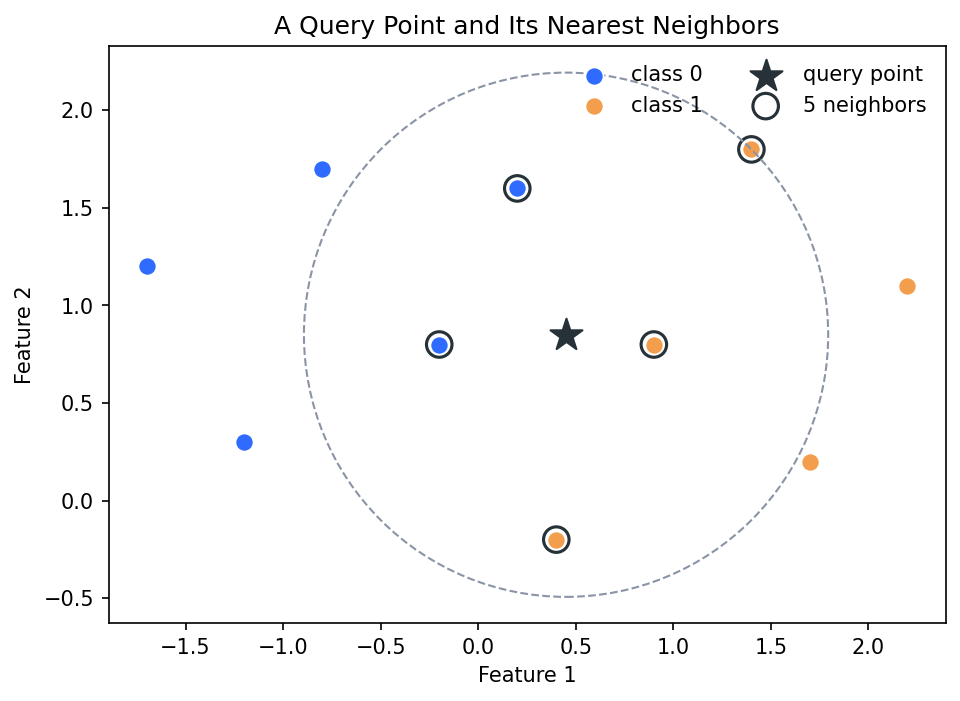

### 1.2 距离度量：Minkowski、Manhattan 与 Euclidean

Minkowski 距离统一写为

$$
d_p(\boldsymbol x,\boldsymbol z)
=\left(\sum_{j=1}^{d}|x_j-z_j|^p\right)^{1/p}.
$$

- (p=1)：Manhattan 距离，沿坐标轴累加绝对差；
- (p=2)：Euclidean 距离，即通常所说的直线距离；
- (p\to\infty)：Chebyshev 距离，只看最大坐标差。

距离决定“谁是邻居”，因此并非无关紧要的技术细节。本章手写部分使用 Euclidean 距离。

### 1.3 分类决策：多数投票与类别概率

无权投票对类别 (c) 的计数为

$$
s_c(\boldsymbol x)=\sum_{i\in\mathcal N_k(\boldsymbol x)}\mathbb I(y_i=c),
\qquad
\hat y=\arg\max_c s_c(\boldsymbol x).
$$

类别概率可用邻居比例估计：

$$
\hat P(y=c\mid\boldsymbol x)=\frac{s_c(\boldsymbol x)}{k}.
$$

若希望更近的样本影响更大，可以取

$$
w_i=\frac{1}{d(\boldsymbol x,\boldsymbol x_i)+\varepsilon},\qquad
\hat P(y=c\mid\boldsymbol x)=
\frac{\sum_{i\in\mathcal N_k}w_i\mathbb I(y_i=c)}{\sum_{i\in\mathcal N_k}w_i}.
$$

### 1.4 回归决策：邻居平均与距离加权

当目标是连续值时，多数投票改为邻居均值：

$$
\hat y(\boldsymbol x)=\frac1k\sum_{i\in\mathcal N_k(\boldsymbol x)}y_i.
$$

距离加权回归为

$$
\hat y(\boldsymbol x)=
\frac{\sum_{i\in\mathcal N_k}w_i y_i}{\sum_{i\in\mathcal N_k}w_i}.
$$

分类与回归使用同一条主线：**找邻居 → 汇总邻居的目标**；区别只是汇总方式。

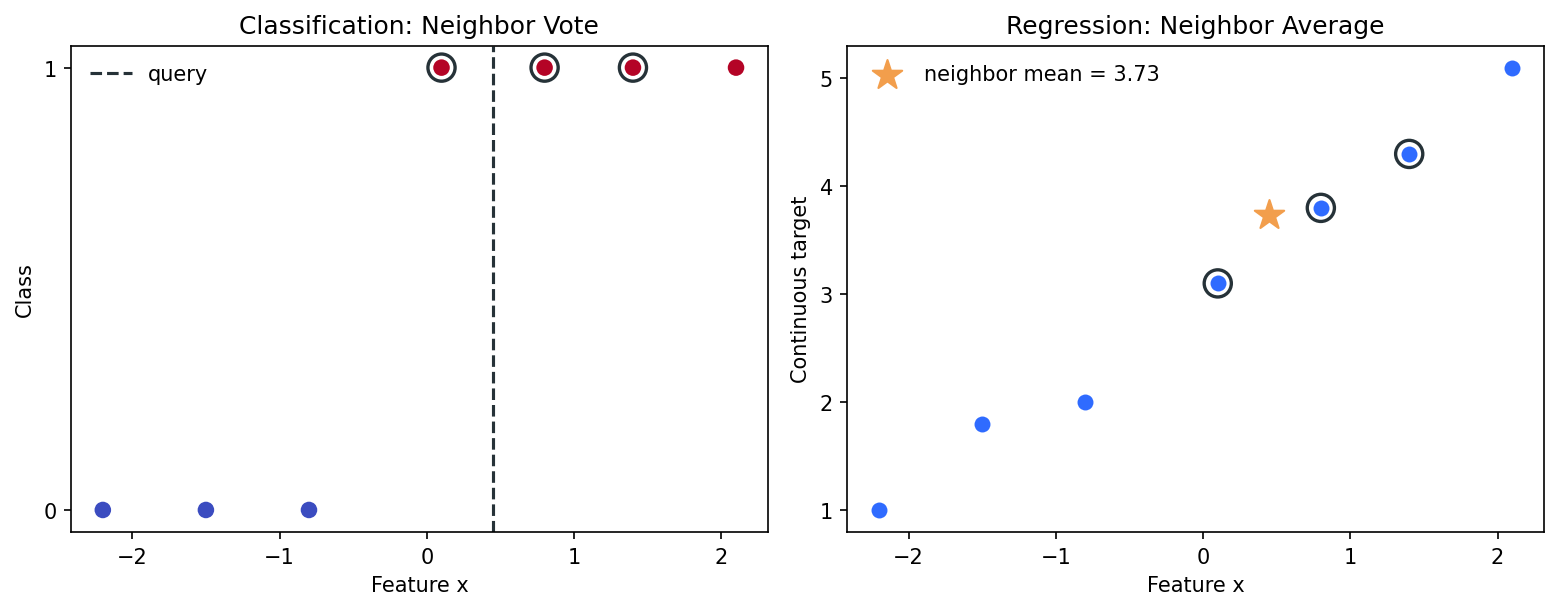

### 1.5 参数影响：k 与偏差—方差

- (k=1) 时边界非常灵活，训练误差低，但容易把噪声也当成规律；
- (k) 增大时预测更平滑，方差下降，但可能掩盖局部结构而欠拟合；
- 因此 (k) 应通过验证集或交叉验证选择，而不是只看训练 Accuracy。

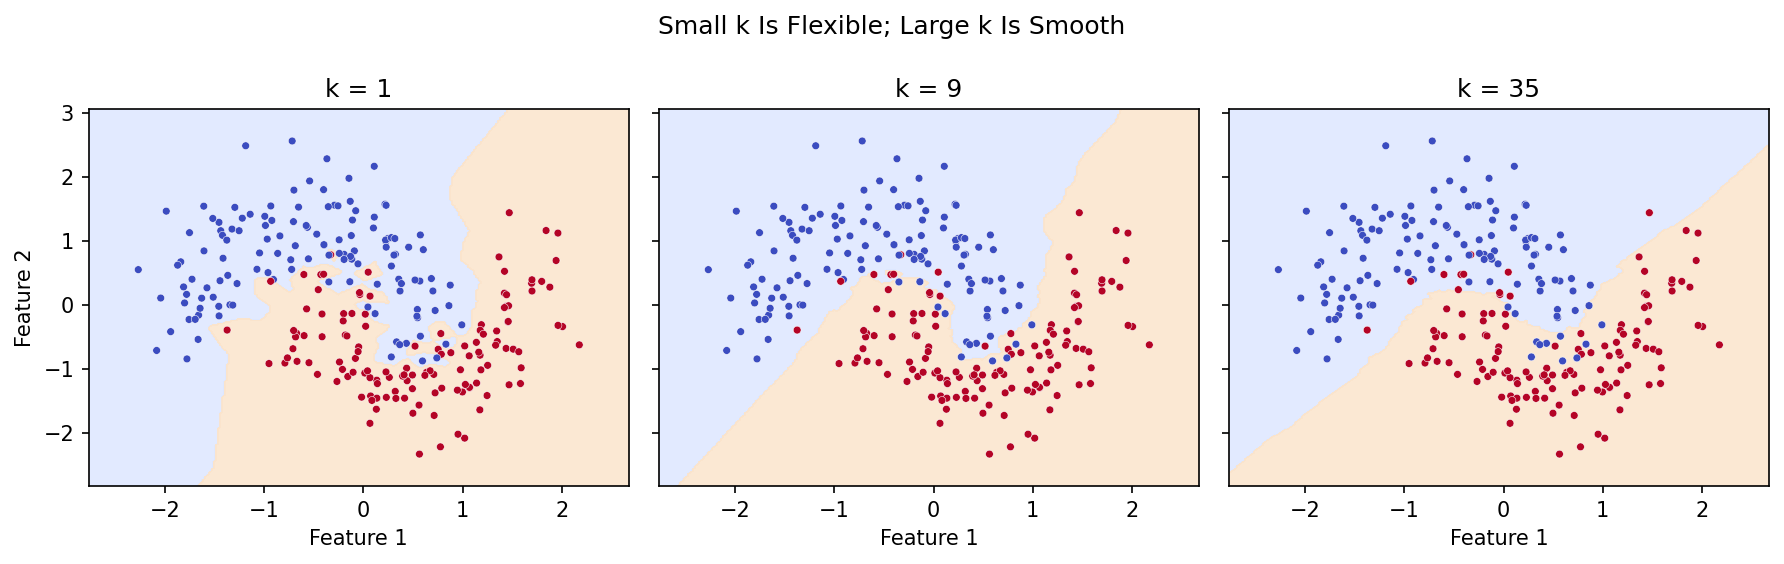

### 1.6 数据尺度：为什么需要标准化

假设“年龄”范围为 20–80，而“年收入”范围为 20 000–1 000 000。直接计算 Euclidean 距离时，
收入的数值尺度会压倒年龄。标准化

$$
x'_j=\frac{x_j-\mu_j}{\sigma_j}
$$

让各特征在相近尺度上参与距离计算。必须只用训练集估计 (\mu_j,\sigma_j)，避免数据泄漏。

### 1.7 高维限制：维数灾难与计算复杂度

随维数增加，样本会变得稀疏，最近邻与较远邻居之间的距离差异变小，局部邻域不再可靠，
这就是 KNN 的维数灾难。暴力预测一个查询点需要比较全部样本，约为 (O(nd))；
KD Tree、Ball Tree 可加速部分低维问题，但高维时效果会减弱。

### 1.8 完整链路：从距离到预测

```text
训练数据 → 仅用训练集完成标准化 → 保存样本
         → 新样本采用同一变换 → 计算距离 → 选择 k 个邻居
         → 分类：投票/概率；回归：均值/加权均值 → 指标与图形评估
```

KNN 是非参数模型：这里的“非参数”不是没有超参数，而是不预先假设固定形式的全局预测函数。

<a id="scratch"></a>
## 2. NumPy 手写 KNN 分类器

### 2.1 图形复现：三张核心原理图

以下三段代码分别复现邻域几何、不同 `k` 的边界，以及分类投票与回归平均的统一视角。

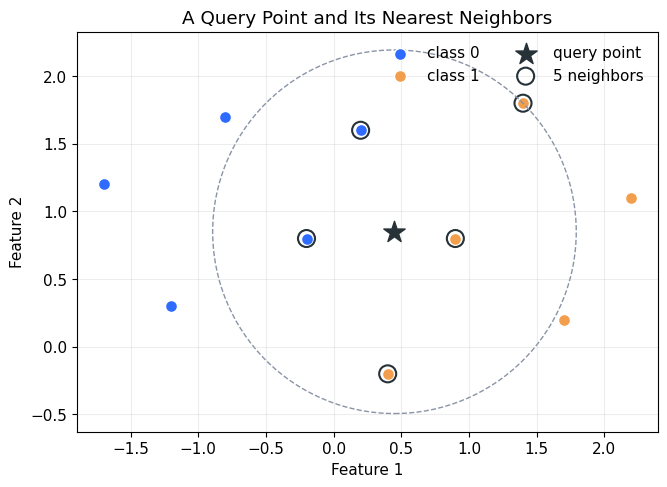

In [1]:
# 复现图 1：查询点与最近邻
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

BLUE, ORANGE, DARK, GREY = "#2F6BFF", "#F29E4C", "#263238", "#8A94A6"
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.22, "font.size": 11})

geometry_X = np.array([
    [-1.7, 1.2], [-1.2, 0.3], [-0.8, 1.7], [-0.2, 0.8], [0.2, 1.6],
    [0.4, -0.2], [0.9, 0.8], [1.4, 1.8], [1.7, 0.2], [2.2, 1.1],
])
geometry_y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
query = np.array([0.45, 0.85])
geometry_distances = np.sqrt(np.sum((geometry_X - query) ** 2, axis=1))
geometry_neighbors = np.argsort(geometry_distances)[:5]

fig, ax = plt.subplots(figsize=(7.2, 5.0))
for label, color in [(0, BLUE), (1, ORANGE)]:
    mask = geometry_y == label
    ax.scatter(geometry_X[mask, 0], geometry_X[mask, 1], s=75, color=color,
               edgecolor="white", label=f"class {label}")
ax.scatter(*query, marker="*", s=260, color=DARK, label="query point", zorder=5)
ax.scatter(geometry_X[geometry_neighbors, 0], geometry_X[geometry_neighbors, 1],
           s=150, facecolors="none", edgecolors=DARK, linewidths=1.5,
           label="5 neighbors")
ax.add_patch(plt.Circle(query, geometry_distances[geometry_neighbors[-1]],
                       fill=False, color=GREY, linestyle="--"))
ax.set(title="A Query Point and Its Nearest Neighbors",
       xlabel="Feature 1", ylabel="Feature 2", aspect="equal")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepd

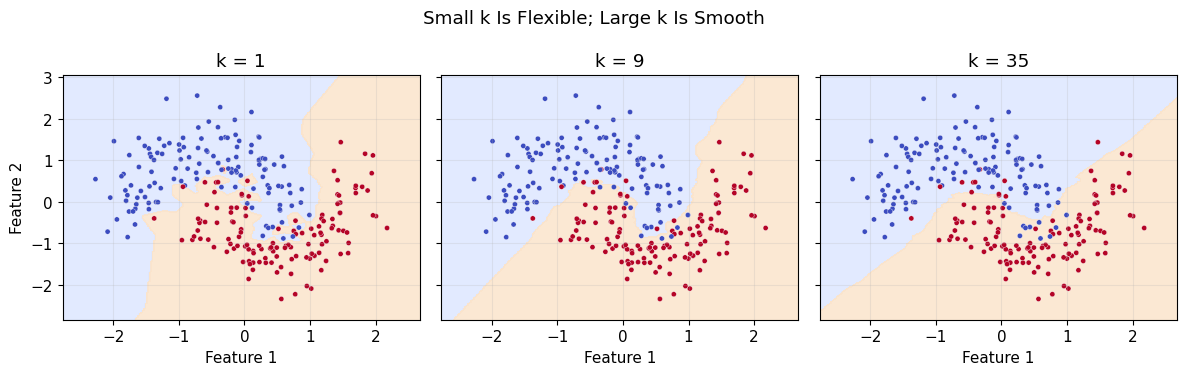

In [2]:
# 复现图 2：不同 k 的决策边界
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

figure_X, figure_y = make_moons(n_samples=260, noise=0.24, random_state=42)
figure_X = StandardScaler().fit_transform(figure_X)
x_min, x_max = figure_X[:, 0].min() - 0.5, figure_X[:, 0].max() + 0.5
y_min, y_max = figure_X[:, 1].min() - 0.5, figure_X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.c_[xx.ravel(), yy.ravel()]
regions = ListedColormap(["#DDE7FF", "#FBE4CC"])

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.8), sharex=True, sharey=True)
for ax, k in zip(axes, (1, 9, 35)):
    figure_model = KNeighborsClassifier(n_neighbors=k).fit(figure_X, figure_y)
    region = figure_model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, region, cmap=regions, alpha=0.85)
    ax.scatter(figure_X[:, 0], figure_X[:, 1], c=figure_y, cmap="coolwarm",
               s=14, edgecolor="white", linewidth=0.25)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
fig.suptitle("Small k Is Flexible; Large k Is Smooth")
plt.tight_layout()
plt.show()

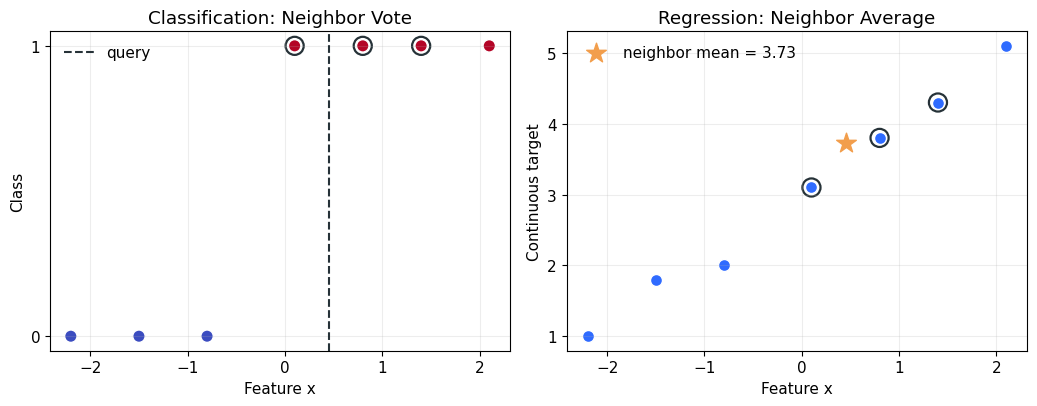

In [3]:
# 复现图 3：分类投票与回归平均
neighbor_x = np.array([-2.2, -1.5, -0.8, 0.1, 0.8, 1.4, 2.1])
neighbor_class = np.array([0, 0, 0, 1, 1, 1, 1])
neighbor_target = np.array([1.0, 1.8, 2.0, 3.1, 3.8, 4.3, 5.1])
neighbor_query = 0.45
nearest_three = np.argsort(np.abs(neighbor_x - neighbor_query))[:3]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].scatter(neighbor_x, neighbor_class, c=neighbor_class, cmap="coolwarm",
                s=80, edgecolor="white")
axes[0].scatter(neighbor_x[nearest_three], neighbor_class[nearest_three], s=170,
                facecolors="none", edgecolors=DARK, linewidths=1.6)
axes[0].axvline(neighbor_query, color=DARK, linestyle="--", label="query")
axes[0].set(yticks=[0, 1], xlabel="Feature x", ylabel="Class",
            title="Classification: Neighbor Vote")
axes[0].legend(frameon=False)

axes[1].scatter(neighbor_x, neighbor_target, color=BLUE, s=75, edgecolor="white")
axes[1].scatter(neighbor_x[nearest_three], neighbor_target[nearest_three], s=170,
                facecolors="none", edgecolors=DARK, linewidths=1.6)
neighbor_mean = neighbor_target[nearest_three].mean()
axes[1].scatter(neighbor_query, neighbor_mean, marker="*", s=220, color=ORANGE,
                label=f"neighbor mean = {neighbor_mean:.2f}")
axes[1].set(xlabel="Feature x", ylabel="Continuous target",
            title="Regression: Neighbor Average")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

### 2.2 数据准备：二维月牙模拟数据

使用 `make_moons` 生成非线性二分类数据。为了避免数据泄漏，均值和标准差只由训练集计算，
测试集使用同一变换。

In [4]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split

manual_X, manual_y = make_moons(n_samples=360, noise=0.22, random_state=42)
manual_X_train, manual_X_test, manual_y_train, manual_y_test = train_test_split(
    manual_X, manual_y, test_size=0.25, stratify=manual_y, random_state=42
)
manual_mean = manual_X_train.mean(axis=0)
manual_std = manual_X_train.std(axis=0)
manual_X_train_scaled = (manual_X_train - manual_mean) / manual_std
manual_X_test_scaled = (manual_X_test - manual_mean) / manual_std
print(f"Training samples: {len(manual_X_train)}; test samples: {len(manual_X_test)}")

Training samples: 270; test samples: 90


### 2.3 模型实现：`KNNClassifierScratch`

`fit` 只保存数据；`kneighbors` 排序距离；`predict_proba` 汇总邻居权重；
`predict` 选择概率最大的类别。遇到完全重合的训练样本时，只让零距离样本参与投票。

In [5]:
class KNNClassifierScratch:
    def __init__(self, n_neighbors=5, weights="uniform"):
        self.n_neighbors = int(n_neighbors)
        self.weights = weights

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        if X.ndim != 2 or len(X) != len(y) or len(X) == 0:
            raise ValueError("X and y must contain the same non-zero number of samples")
        if not 1 <= self.n_neighbors <= len(X):
            raise ValueError("n_neighbors must be between 1 and the number of samples")
        if self.weights not in {"uniform", "distance"}:
            raise ValueError("weights must be 'uniform' or 'distance'")
        self.X_train_ = X
        self.y_train_ = y
        self.classes_ = np.unique(y)
        return self

    def _distances(self, X):
        X = np.asarray(X, dtype=float)
        differences = X[:, None, :] - self.X_train_[None, :, :]
        return np.sqrt(np.sum(differences ** 2, axis=2))

    def kneighbors(self, X):
        distances = self._distances(X)
        indices = np.argsort(distances, axis=1)[:, :self.n_neighbors]
        neighbor_distances = np.take_along_axis(distances, indices, axis=1)
        return neighbor_distances, indices

    def predict_proba(self, X):
        neighbor_distances, neighbor_indices = self.kneighbors(X)
        neighbor_labels = self.y_train_[neighbor_indices]
        probabilities = np.zeros((len(neighbor_labels), len(self.classes_)))

        for row_index, (distances, labels) in enumerate(
            zip(neighbor_distances, neighbor_labels)
        ):
            if self.weights == "uniform":
                vote_weights = np.ones_like(distances)
            elif np.any(distances == 0):
                vote_weights = (distances == 0).astype(float)
            else:
                vote_weights = 1.0 / np.maximum(distances, 1e-12)

            for class_index, class_value in enumerate(self.classes_):
                probabilities[row_index, class_index] = vote_weights[
                    labels == class_value
                ].sum()
            probabilities[row_index] /= probabilities[row_index].sum()
        return probabilities

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]

### 2.4 训练评估：边界、矩阵与 ROC

手写模型使用距离加权。分类的固定阈值表现由 Accuracy、Precision、Recall、F1 和混淆矩阵检查，
全部阈值下的排序能力由 ROC-AUC 检查。

In [6]:
def evaluate_binary(y_true, y_pred, y_probability):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_probability),
    }

def plot_probability_boundary(
    model, X, y, title,
    x_label="Feature 1", y_label="Feature 2",
):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probability = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(7.2, 5.4))
    contour = ax.contourf(xx, yy, probability, levels=np.linspace(0, 1, 11),
                          cmap="RdBu_r", alpha=0.55)
    ax.contour(xx, yy, probability, levels=[0.5], colors=DARK, linewidths=1.6)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=38,
               edgecolor="white", linewidth=0.5)
    ax.set(xlabel=x_label, ylabel=y_label, title=title)
    fig.colorbar(contour, ax=ax, label="P(y=1)")
    plt.tight_layout()
    plt.show()

def plot_binary_evaluation(y_true, y_pred, y_probability, title, labels):
    false_positive_rate, true_positive_rate, _ = roc_curve(y_true, y_probability)
    auc_value = roc_auc_score(y_true, y_probability)
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.7))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=labels, cmap="Blues",
        colorbar=False, ax=axes[0]
    )
    axes[0].set_title("Confusion Matrix")
    axes[0].grid(False)
    axes[1].plot(false_positive_rate, true_positive_rate, color=BLUE,
                 linewidth=2.2, label=f"KNN (AUC={auc_value:.3f})")
    axes[1].plot([0, 1], [0, 1], "--", color=GREY, label="Random classifier")
    axes[1].set(xlabel="False Positive Rate", ylabel="True Positive Rate",
                title="ROC Curve")
    axes[1].legend(frameon=False, loc="lower right")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

manual_model = KNNClassifierScratch(n_neighbors=9, weights="distance").fit(
    manual_X_train_scaled, manual_y_train
)
manual_probability = manual_model.predict_proba(manual_X_test_scaled)
manual_prediction = manual_model.predict(manual_X_test_scaled)
manual_metrics = evaluate_binary(
    manual_y_test, manual_prediction, manual_probability[:, 1]
)
probability_row_sum_error = float(
    np.max(np.abs(manual_probability.sum(axis=1) - 1.0))
)
assert probability_row_sum_error < 1e-12
assert manual_metrics["Accuracy"] >= 0.80
for name, value in manual_metrics.items():
    print(f"{name:9s}: {value:.4f}")
print("手写模型验证通过。")

Accuracy : 0.9222
Precision: 0.9524
Recall   : 0.8889
F1       : 0.9195
ROC-AUC  : 0.9662
手写模型验证通过。


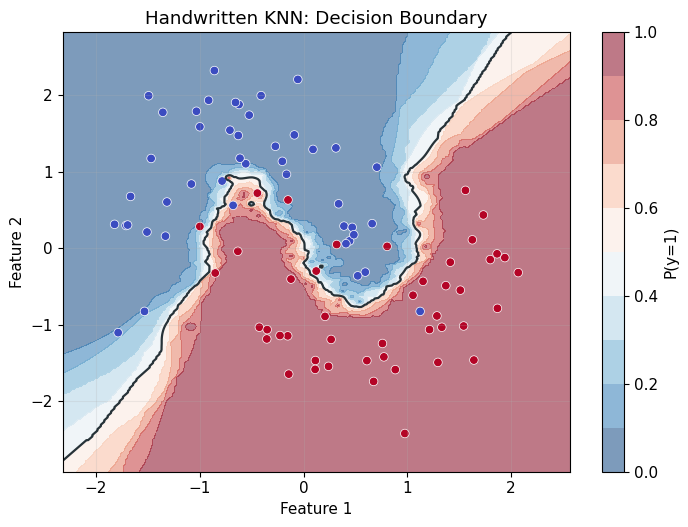

In [7]:
plot_probability_boundary(
    manual_model, manual_X_test_scaled, manual_y_test,
    "Handwritten KNN: Decision Boundary"
)

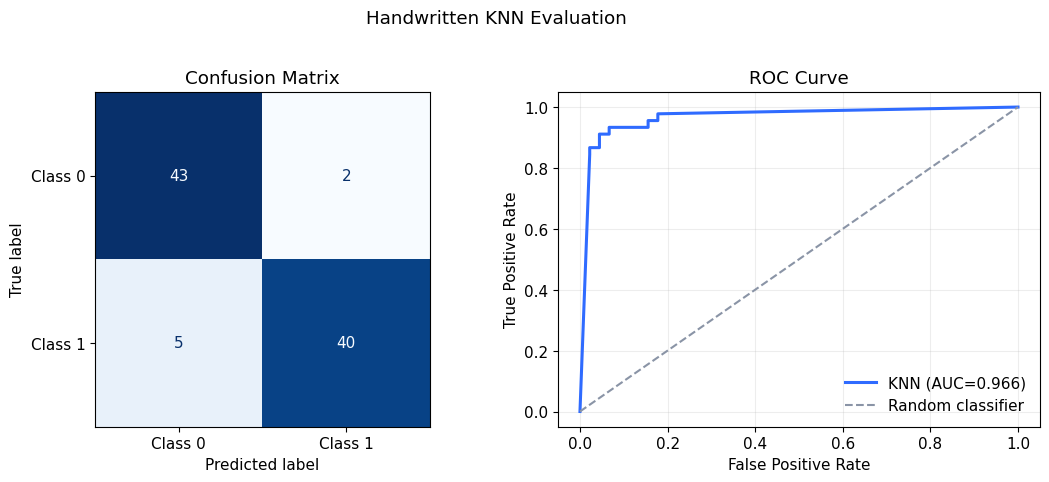

In [8]:
plot_binary_evaluation(
    manual_y_test, manual_prediction, manual_probability[:, 1],
    "Handwritten KNN Evaluation", ["Class 0", "Class 1"]
)

### 2.5 参数实验：k 与泛化能力

只改变 `k`，比较训练集与测试集 Accuracy。训练表现通常随 `k` 增大而下降，
测试表现则可能先改善后下降，这正是偏差—方差权衡的可见结果。

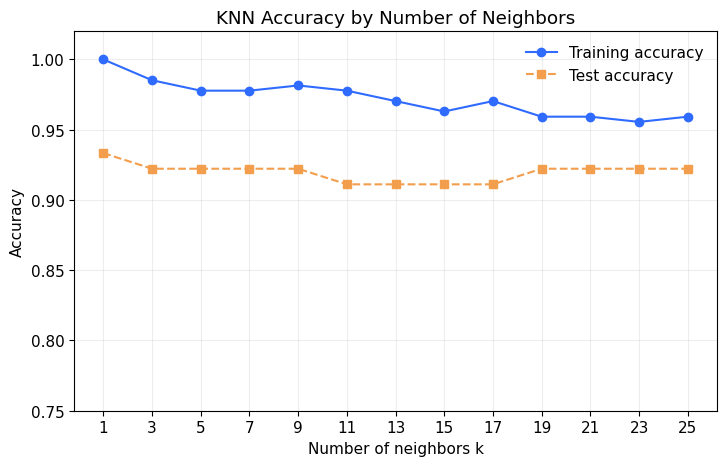

In [9]:
k_values = list(range(1, 26, 2))
k_train_accuracy, k_test_accuracy = [], []
for k in k_values:
    k_model = KNNClassifierScratch(n_neighbors=k).fit(
        manual_X_train_scaled, manual_y_train
    )
    k_train_accuracy.append(
        accuracy_score(manual_y_train, k_model.predict(manual_X_train_scaled))
    )
    k_test_accuracy.append(
        accuracy_score(manual_y_test, k_model.predict(manual_X_test_scaled))
    )

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(k_values, k_train_accuracy, "o-", color=BLUE, label="Training accuracy")
ax.plot(k_values, k_test_accuracy, "s--", color=ORANGE, label="Test accuracy")
ax.set(xlabel="Number of neighbors k", ylabel="Accuracy",
       title="KNN Accuracy by Number of Neighbors", xticks=k_values, ylim=(0.75, 1.02))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

<a id="sklearn"></a>
## 3. sklearn 调用与案例

<a id="sklearn-basic"></a>
### 3.1 分类调用：二维边界与指标评估

基础案例沿用二维月牙数据，使用 Pipeline 保证标准化只由训练集学习，
并展示完整的边界、混淆矩阵和 ROC。

In [10]:
from IPython.display import HTML, display
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def display_result_table(title, headers, rows, hidden_comment=""):
    header_html = "".join(
        f'<th style="padding:8px 12px;text-align:left;background:#eef3ff">{header}</th>'
        for header in headers
    )
    row_html = "".join(
        "<tr>" + "".join(
            f'<td style="padding:7px 12px;border-top:1px solid #dde3ee">{value}</td>'
            for value in row
        ) + "</tr>" for row in rows
    )
    comment_html = f"<!-- {hidden_comment} -->" if hidden_comment else ""
    display(HTML(
        f'<div style="max-width:780px"><h4>{title}</h4>'
        f'<table style="border-collapse:collapse;width:100%;font-size:14px">'
        f'<thead><tr>{header_html}</tr></thead><tbody>{row_html}</tbody></table>'
        f'{comment_html}</div>'
    ))

basic_X, basic_y = make_moons(n_samples=360, noise=0.22, random_state=7)
basic_X_train, basic_X_test, basic_y_train, basic_y_test = train_test_split(
    basic_X, basic_y, test_size=0.25, stratify=basic_y, random_state=42
)
basic_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=9, weights="distance"),
).fit(basic_X_train, basic_y_train)
basic_probability = basic_model.predict_proba(basic_X_test)[:, 1]
basic_prediction = basic_model.predict(basic_X_test)
basic_metrics = evaluate_binary(basic_y_test, basic_prediction, basic_probability)
print("基础分类")
for name, value in basic_metrics.items():
    print(f"{name:9s}: {value:.4f}")

基础分类
Accuracy : 0.9667
Precision: 0.9565
Recall   : 0.9778
F1       : 0.9670
ROC-AUC  : 0.9790


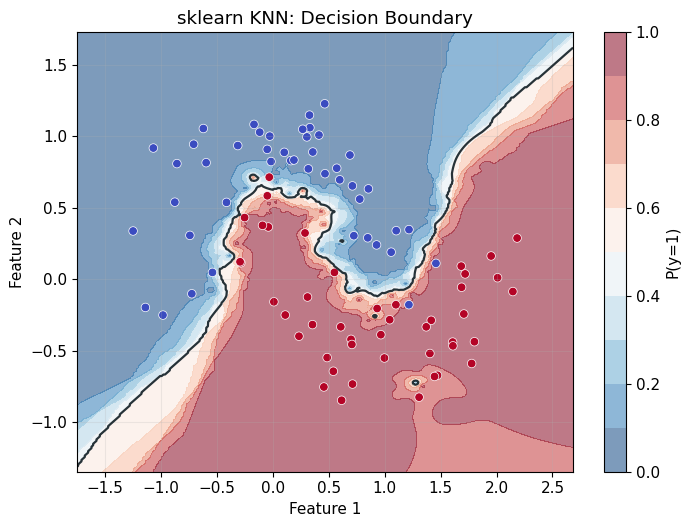

In [11]:
plot_probability_boundary(
    basic_model, basic_X_test, basic_y_test,
    "sklearn KNN: Decision Boundary"
)

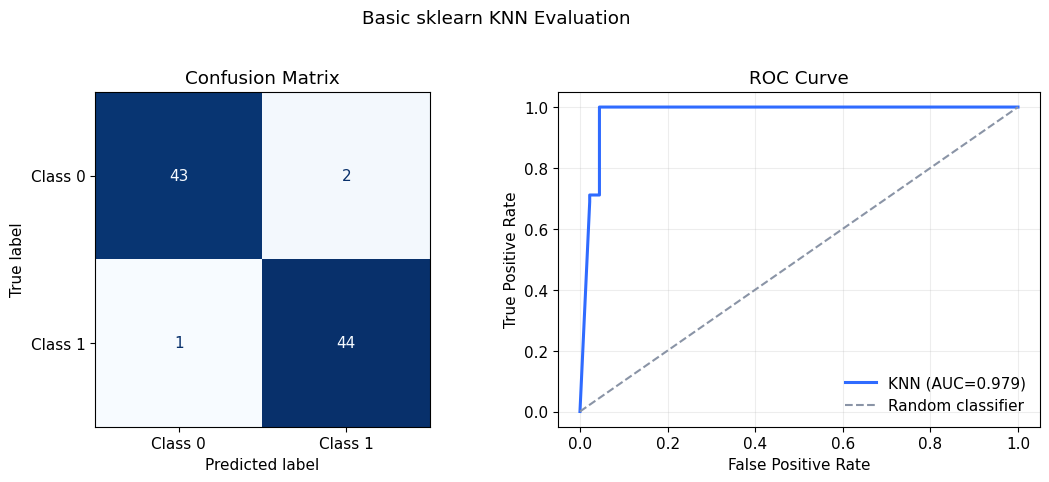

In [12]:
plot_binary_evaluation(
    basic_y_test, basic_prediction, basic_probability,
    "Basic sklearn KNN Evaluation", ["Class 0", "Class 1"]
)

<a id="real-case"></a>
### 3.2 分类案例：乳腺癌良恶性诊断

正式模型使用全部 30 个特征，指标、混淆矩阵和 ROC 均来自完整模型。
30 维真实边界无法直接画在二维平面，因此另建 PCA 投影模型：
**PCA 二维投影边界（仅用于可视化）**，不代替完整模型的性能结论。

In [13]:
cancer = load_breast_cancer()
real_X_train, real_X_test, real_y_train, real_y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.20,
    stratify=cancer.target, random_state=42
)
real_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=11, weights="distance"),
).fit(real_X_train, real_y_train)
real_probability = real_model.predict_proba(real_X_test)[:, 1]
real_prediction = real_model.predict(real_X_test)
real_metrics = evaluate_binary(real_y_test, real_prediction, real_probability)
print("真实分类案例：乳腺癌良恶性诊断")
display_result_table(
    "乳腺癌 KNN 真实案例指标表",
    ["指标", "数值", "含义"],
    [
        ["Accuracy", f'{real_metrics["Accuracy"]:.3f}', "总体预测正确率"],
        ["Precision", f'{real_metrics["Precision"]:.3f}', "预测为正类时的准确程度"],
        ["Recall", f'{real_metrics["Recall"]:.3f}', "实际正类被识别的比例"],
        ["F1", f'{real_metrics["F1"]:.3f}', "Precision 与 Recall 的调和平均"],
        ["ROC-AUC", f'{real_metrics["ROC-AUC"]:.3f}', "全部阈值下的排序能力"],
    ],
)

真实分类案例：乳腺癌良恶性诊断


指标,数值,含义
Accuracy,0.974,总体预测正确率
Precision,0.960,预测为正类时的准确程度
Recall,1.000,实际正类被识别的比例
F1,0.980,Precision 与 Recall 的调和平均
ROC-AUC,0.992,全部阈值下的排序能力


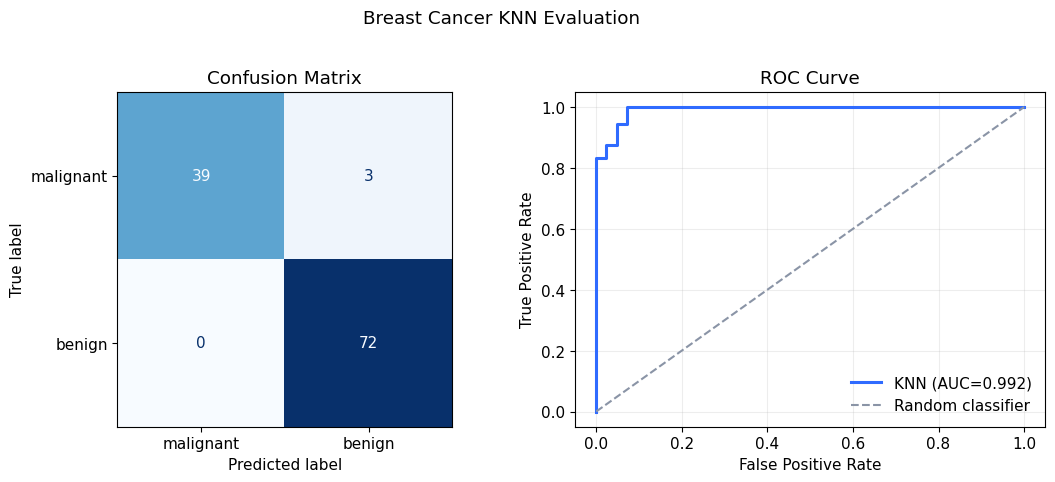

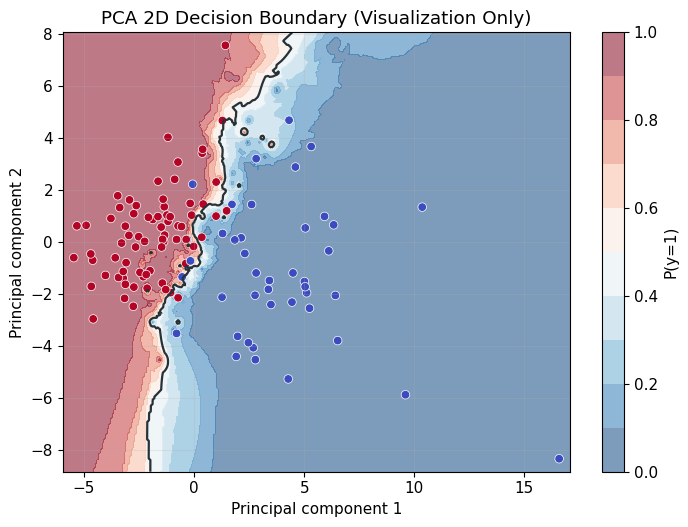

In [14]:
plot_binary_evaluation(
    real_y_test, real_prediction, real_probability,
    "Breast Cancer KNN Evaluation", list(cancer.target_names)
)

real_visual_scaler = StandardScaler().fit(real_X_train)
real_X_train_scaled = real_visual_scaler.transform(real_X_train)
real_X_test_scaled = real_visual_scaler.transform(real_X_test)
real_visual_pca = PCA(n_components=2, random_state=42).fit(real_X_train_scaled)
real_X_train_pca = real_visual_pca.transform(real_X_train_scaled)
real_X_test_pca = real_visual_pca.transform(real_X_test_scaled)
real_visual_model = KNeighborsClassifier(
    n_neighbors=11, weights="distance"
).fit(real_X_train_pca, real_y_train)
plot_probability_boundary(
    real_visual_model, real_X_test_pca, real_y_test,
    "PCA 2D Decision Boundary (Visualization Only)",
    x_label="Principal component 1",
    y_label="Principal component 2",
)

<a id="regression-case"></a>
### 3.3 回归调用：邻居平均与糖尿病预测

先用一维数据观察 KNN 回归的局部平均曲线，再用糖尿病数据预测一年后的疾病进展值。
正式回归评估同时展示 MAE、MSE、RMSE、(R^2)、真实值—预测值和残差。

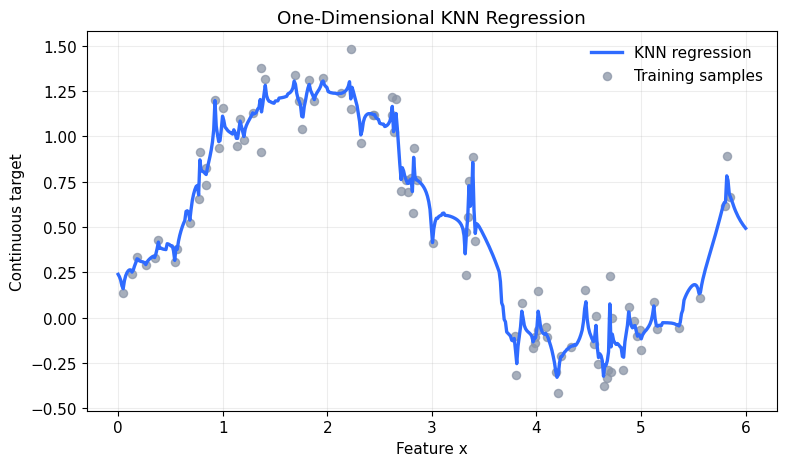

In [15]:
regression_rng = np.random.default_rng(42)
regression_demo_X = np.sort(regression_rng.uniform(0, 6, 90))[:, None]
regression_demo_y = (
    np.sin(regression_demo_X[:, 0])
    + 0.18 * regression_demo_X[:, 0]
    + regression_rng.normal(0, 0.18, len(regression_demo_X))
)
regression_demo_grid = np.linspace(0, 6, 500)[:, None]
regression_demo_model = KNeighborsRegressor(
    n_neighbors=9, weights="distance"
).fit(regression_demo_X, regression_demo_y)
regression_demo_prediction = regression_demo_model.predict(regression_demo_grid)

fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.scatter(regression_demo_X[:, 0], regression_demo_y, color=GREY,
           s=34, alpha=0.75, label="Training samples")
ax.plot(regression_demo_grid[:, 0], regression_demo_prediction,
        color=BLUE, linewidth=2.4, label="KNN regression")
ax.set(xlabel="Feature x", ylabel="Continuous target",
       title="One-Dimensional KNN Regression")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [16]:
diabetes = load_diabetes()
diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.20, random_state=42
)
diabetes_model = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=15, weights="distance", p=2),
).fit(diabetes_X_train, diabetes_y_train)
diabetes_prediction = diabetes_model.predict(diabetes_X_test)
diabetes_mae = mean_absolute_error(diabetes_y_test, diabetes_prediction)
regression_mse = mean_squared_error(diabetes_y_test, diabetes_prediction)
diabetes_rmse = np.sqrt(regression_mse)
diabetes_r2 = r2_score(diabetes_y_test, diabetes_prediction)
diabetes_residuals = diabetes_y_test - diabetes_prediction

print("回归案例：糖尿病进展预测")
display_result_table(
    "糖尿病 KNN 回归指标表",
    ["指标", "数值", "含义"],
    [
        ["MAE", f"{diabetes_mae:.3f}", "平均绝对预测误差"],
        ["MSE", f"{regression_mse:.3f}", "平方误差的平均值"],
        ["RMSE", f"{diabetes_rmse:.3f}", "与目标同量纲，对大误差更敏感"],
        ["R²", f"{diabetes_r2:.3f}", "相对恒预测均值基线解释的变异"],
    ],
)

回归案例：糖尿病进展预测


指标,数值,含义
MAE,44.577,平均绝对预测误差
MSE,2986.221,平方误差的平均值
RMSE,54.646,与目标同量纲，对大误差更敏感
R²,0.436,相对恒预测均值基线解释的变异


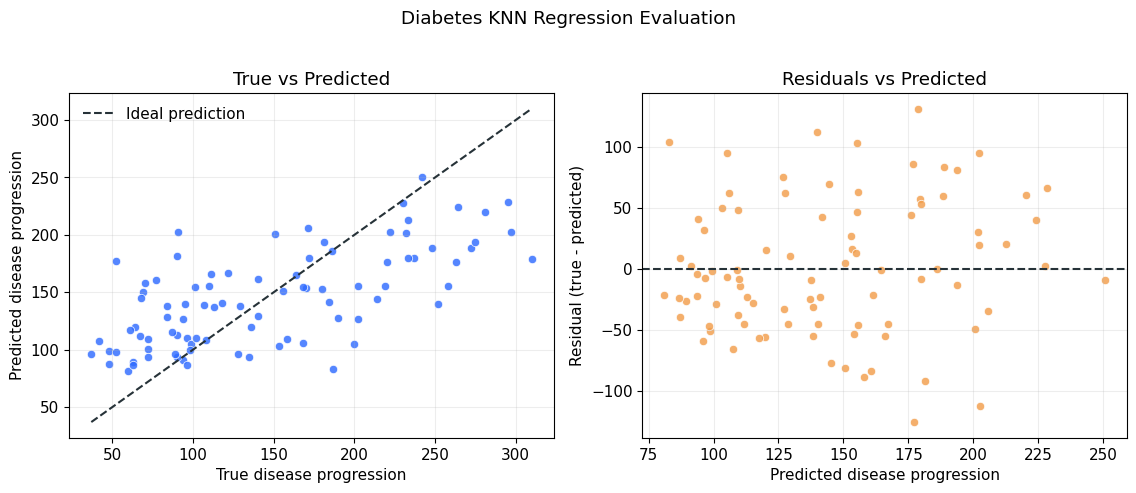

In [17]:
value_min = min(diabetes_y_test.min(), diabetes_prediction.min())
value_max = max(diabetes_y_test.max(), diabetes_prediction.max())
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
axes[0].scatter(diabetes_y_test, diabetes_prediction, color=BLUE,
                edgecolor="white", linewidth=0.6, alpha=0.82)
axes[0].plot([value_min, value_max], [value_min, value_max], "--",
             color=DARK, label="Ideal prediction")
axes[0].set(xlabel="True disease progression", ylabel="Predicted disease progression",
            title="True vs Predicted")
axes[0].legend(frameon=False)
axes[1].scatter(diabetes_prediction, diabetes_residuals, color=ORANGE,
                edgecolor="white", linewidth=0.6, alpha=0.82)
axes[1].axhline(0, color=DARK, linestyle="--", linewidth=1.5)
axes[1].set(xlabel="Predicted disease progression", ylabel="Residual (true - predicted)",
            title="Residuals vs Predicted")
fig.suptitle("Diabetes KNN Regression Evaluation", y=1.02)
plt.tight_layout()
plt.show()

<a id="summary"></a>
## 4. 章节小结

- KNN 不预先拟合全局函数，而是在预测时寻找局部邻居。
- 分类通过多数投票或加权投票，回归通过均值或加权均值；二者共享同一邻域机制。
- `k` 控制局部灵活性与平滑程度，应通过验证集或交叉验证选择。
- KNN 对特征尺度敏感，标准化必须只从训练集学习；高维空间会削弱距离的区分力。
- 分类结合边界、混淆矩阵和 ROC；回归结合 MAE、MSE、RMSE、R² 与残差分析。

In [18]:
validation = {
    "manual_accuracy": float(manual_metrics["Accuracy"]),
    "manual_probability_row_sum_error": float(probability_row_sum_error),
    "basic_accuracy": float(basic_metrics["Accuracy"]),
    "basic_roc_auc": float(basic_metrics["ROC-AUC"]),
    "cancer_accuracy": float(real_metrics["Accuracy"]),
    "cancer_roc_auc": float(real_metrics["ROC-AUC"]),
    "diabetes_mae": float(diabetes_mae),
    "diabetes_mse": float(regression_mse),
    "diabetes_rmse": float(diabetes_rmse),
    "diabetes_r2": float(diabetes_r2),
    "image_count": 12,
}
assert np.all(np.isfinite(list(validation.values())))
assert validation["manual_probability_row_sum_error"] < 1e-12
assert validation["manual_accuracy"] >= 0.80
assert validation["basic_accuracy"] >= 0.80
assert validation["cancer_accuracy"] >= 0.85
assert validation["cancer_roc_auc"] >= 0.85
assert validation["diabetes_r2"] >= 0.15

display_result_table(
    "Notebook 验证汇总（Notebook validation summary）",
    ["检查项", "观测值", "状态"],
    [
        ["手写 KNN Accuracy", f'{validation["manual_accuracy"]:.3f}', "通过"],
        ["基础分类 Accuracy", f'{validation["basic_accuracy"]:.3f}', "通过"],
        ["乳腺癌 Accuracy", f'{validation["cancer_accuracy"]:.3f}', "通过"],
        ["乳腺癌 ROC-AUC", f'{validation["cancer_roc_auc"]:.3f}', "通过"],
        ["糖尿病回归 R²", f'{validation["diabetes_r2"]:.3f}', "通过"],
        ["已执行图表输出", f'{validation["image_count"]}', "通过"],
    ],
    hidden_comment="VALIDATION " + json.dumps(
        validation, ensure_ascii=False, sort_keys=True
    ),
)

检查项,观测值,状态
手写 KNN Accuracy,0.922,通过
基础分类 Accuracy,0.967,通过
乳腺癌 Accuracy,0.974,通过
乳腺癌 ROC-AUC,0.992,通过
糖尿病回归 R²,0.436,通过
已执行图表输出,12,通过
